In [20]:
import numpy as np 
import pandas as pd 
import torch 
import torch.nn as nn
import torch.optim as optim 

from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report 
from sklearn.metrics import auc, roc_auc_score, precision_recall_curve, precision_score, recall_score, fbeta_score, f1_score 



In [21]:
np.random.seed(10)
samples = 100_000
df = pd.DataFrame({
    'a': np.random.randn(samples),
    'b': np.random.randn(samples),
    'c': np.random.randn(samples),
    'd': np.random.choice(['x', 'y', 'z'], samples),
})

def gen_click(row):
    val = (row['a'] * row['b'] * row['c'] + (1.0 if row['d'] == 'x' else 0.5 if row['d'] == 'y' else -0.5 if row['d'] == 'z' else -1.0))
    return val > 2.0

df['click'] = df.apply(gen_click, axis=1)

df.to_csv('tmp.csv')

In [22]:
df = pd.read_csv('tmp.csv')
X = df.drop(columns=['click'])
y = df[['click']]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=10)

In [23]:
print(df[['a', 'b', 'c']].describe())
print(df[['d']].value_counts(normalize=True))
print(df[['click']].value_counts(normalize=True))

                   a              b              c
count  100000.000000  100000.000000  100000.000000
mean       -0.002978      -0.001912       0.003935
std         0.999424       0.998629       0.999939
min        -4.281627      -4.206775      -4.427009
25%        -0.677736      -0.676992      -0.668556
50%        -0.002269       0.000097       0.004625
75%         0.668522       0.670387       0.677828
max         4.154608       4.377391       4.441572
d
x    0.33492
y    0.33321
z    0.33187
dtype: float64
click
False    0.95594
True     0.04406
dtype: float64


In [24]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 

num_cols = ['a', 'b', 'c']
cat_cols = ['d']

prep = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(), cat_cols),
    ]
)

X_train = prep.fit_transform(X_train)
X_test = prep.transform(X_test)

print(X_train.shape, X_test.shape)

(80000, 6) (20000, 6)


In [25]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=128, shuffle=True)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=128, shuffle=False)


In [26]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(*[
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), 
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid(),
        ])

    def forward(self, x):
        return self.layers(x)

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def train(model, X_train, y_train, epochs=1, batch=128, lr=0.01):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch, shuffle=True)

    model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        train_loss = 0.0
        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        print(f'{epoch+1}, {train_loss / len(train_loader)}')
    return model

model = MLP(input_dim=X_train.shape[1], output_dim=1, hidden_dim=128)
model = train(model, X_train, y_train)

Using device: cuda
1, 0.0662258848503232


In [28]:
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, precision_score, recall_score, f1_score, fbeta_score


def eval_metrics(labels, pred, prob):
    precision, recall, _ = precision_recall_curve(labels, prob)
    return {
        "accuracy": accuracy_score(labels, pred),
        "f1": f1_score(labels, pred),
        "precission": precision_score(labels, pred),
        "recall": recall_score(labels, pred),
        "roc_auc": roc_auc_score(labels, prob),
        "pr_auc": auc(recall, precision),
    }


def pred(model, X, threshold=0.5):
    X = torch.tensor(X, dtype=torch.float32)
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        y_prob = model(X.to(device)).cpu().numpy()
        y_pred = (y_prob > threshold).astype(np.float32)
    return y_pred, y_prob


def eval(model, X, y, threshold=0.5):
    y_pred, y_prob = pred(model, X, threshold=threshold)
    return eval_metrics(y, y_pred, y_prob)

eval(model, X_test, y_test)

{'accuracy': 0.9856,
 'f1': 0.840531561461794,
 'precission': 0.8205405405405405,
 'recall': 0.8615209988649262,
 'roc_auc': 0.9958441481184902,
 'pr_auc': 0.921881124849273}

In [29]:
from sklearn.isotonic import IsotonicRegression 

def isotonic_calibration(model, X, y):
    y_pred, y_prob = pred(model, X)
    calibrator = IsotonicRegression(out_of_bounds='clip')
    calibrator.fit(y_prob.squeeze(), y.squeeze())
    return calibrator


def pred_with_calibrator(model, X, calibrator, threshold=0.5):
    y_pred, y_prob = pred(model, X)
    calibrated_prob = calibrator.transform(y_prob)
    y_pred = (calibrated_prob > threshold).astype(np.float32)
    return y_pred, y_prob, calibrated_prob


calibrator = isotonic_calibration(model, X_train, y_train)
y_pred, y_prob, calibrated_prob = pred_with_calibrator(model, X_test, calibrator)

print(eval_metrics(y_test, (calibrated_prob > 0.5).astype(np.float32), calibrated_prob))
print(eval_metrics(y_test, (y_prob > 0.5).astype(np.float32), y_prob))
print(eval_metrics(y_test, (calibrated_prob > 0.81).astype(np.float32), calibrated_prob))


{'accuracy': 0.9858, 'f1': 0.8331374853113983, 'precission': 0.8635809987819733, 'recall': 0.8047673098751419, 'roc_auc': 0.9958104265898052, 'pr_auc': 0.9216051138153999}
{'accuracy': 0.9856, 'f1': 0.840531561461794, 'precission': 0.8205405405405405, 'recall': 0.8615209988649262, 'roc_auc': 0.9958441481184902, 'pr_auc': 0.921881124849273}
{'accuracy': 0.98255, 'f1': 0.764983164983165, 'precission': 0.9403973509933775, 'recall': 0.64472190692395, 'roc_auc': 0.9958104265898052, 'pr_auc': 0.9216051138153999}


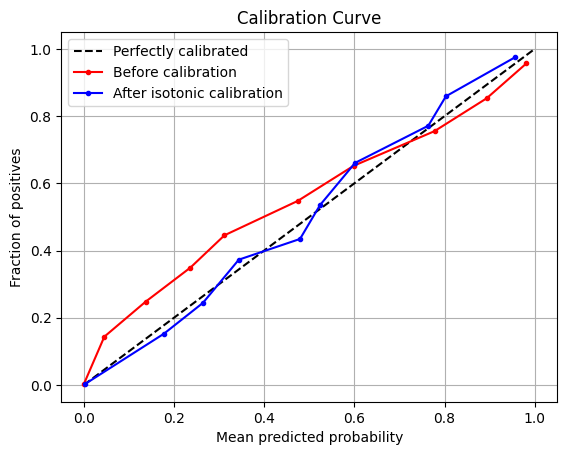

In [30]:

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Plot
plt.figure()
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(*calibration_curve(y_test, y_prob, n_bins=10), 'r.-', label='Before calibration')
plt.plot(*calibration_curve(y_test, calibrated_prob, n_bins=10), 'b.-', label='After isotonic calibration')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()

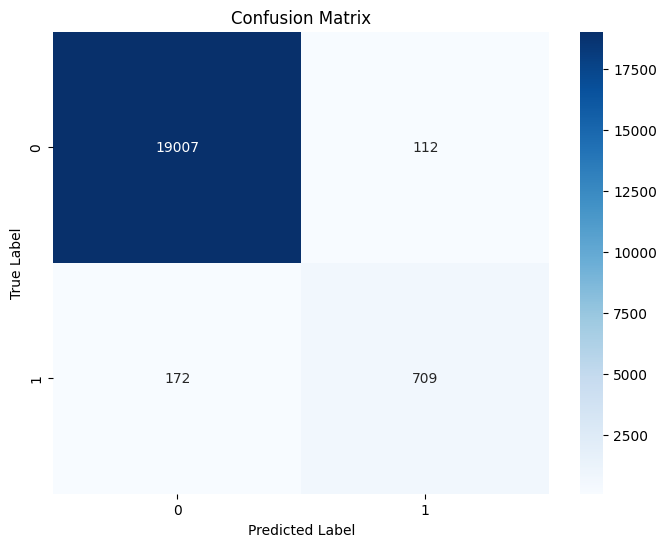

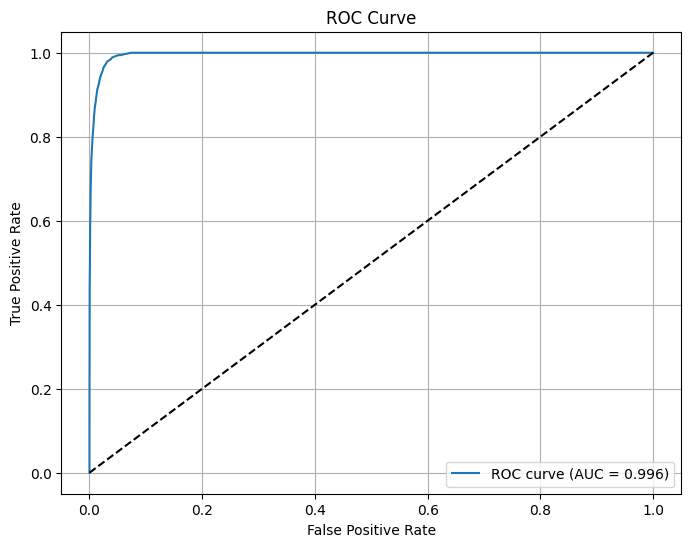

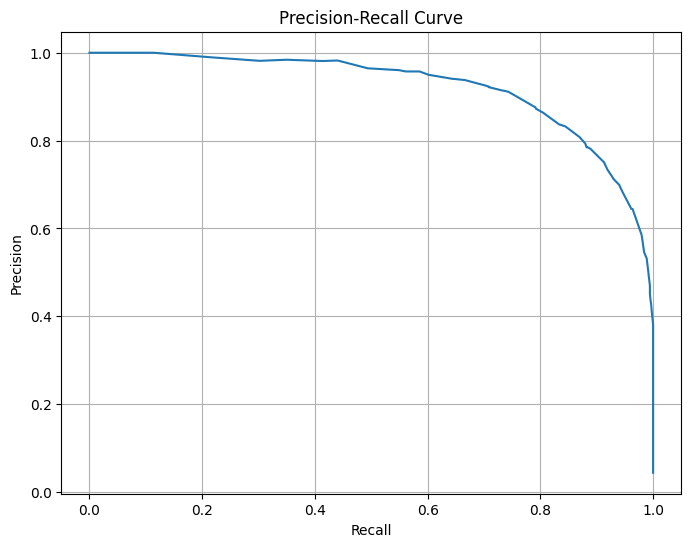

In [31]:
# Additional model evaluation steps:

# 1. Feature importance analysis
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(importances)), importances)
    plt.title('Feature Importances')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.show()

# 2. Confusion Matrix visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 3. ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, calibrated_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, calibrated_prob):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# 4. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, calibrated_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

In [32]:

# 5. Error Analysis
# Find misclassified samples
misclassified = (y_test.values != y_pred)  # Convert to numpy array before comparison
misclassified_count = np.sum(misclassified)
misclassification_rate = np.mean(misclassified)
print("\nNumber of misclassified samples:", misclassified_count)
print("Misclassification rate: {:.2%}".format(misclassification_rate))



Number of misclassified samples: 32593398
Misclassification rate: 8.15%


In [33]:

# 6. Cross-validation scores
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator, ClassifierMixin
# Create a wrapper class for PyTorch model to work with scikit-learn
class TorchClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        
    def fit(self, X, y):
        return self
    
    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(device)
            outputs = self.model(X_tensor)
            predictions = (outputs >= 0.5).cpu().numpy()
        return predictions

# Wrap the model
wrapped_model = TorchClassifierWrapper(model)

# Perform cross-validation
cv_scores = cross_val_score(wrapped_model, X_test, y_test, cv=5)

print("\nCross-validation scores:", cv_scores)
print("Mean CV score: {:.3f} (+/- {:.3f})".format(cv_scores.mean(), cv_scores.std() * 2))



Cross-validation scores: [0.98725 0.98775 0.98325 0.98275 0.987  ]
Mean CV score: 0.986 (+/- 0.004)
